In [537]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

popden = pandas.read_csv("Maryland_Resident_Population_Per_Square_Mile__2010-2024.csv")

In [538]:
# Data Cleaning
for year in popden["Fiscal Year"]:
    year = "2010"

popden["Fiscal Year"] = [str(year)[-4:] for year in popden["Fiscal Year"]]

del popden['Reporting period start date']
del popden['Reporting period end data']
del popden['Date created']


In [539]:
print(popden.head(5))
print(f"The length of popden is: {len(popden)}")

           County  Population density per square mile Fiscal Year
0        Maryland                               594.8        2010
1        Allegany                               176.9        2010
2    Anne Arundel                              1295.8        2010
3  Baltimore City                              7669.2        2010
4       Baltimore                              1346.0        2010
The length of popden is: 425


In [540]:
# Filter out entries that say "Maryland"
temp = [county for county in popden["County"] if county != "Maryland"]

popden = popden[popden["County"].isin(temp)]

In [541]:
print(popden.head(5))

print("\n")
      
print(f"The length of popden is: {len(popden)}")

           County  Population density per square mile Fiscal Year
1        Allegany                               176.9        2010
2    Anne Arundel                              1295.8        2010
3  Baltimore City                              7669.2        2010
4       Baltimore                              1346.0        2010
5         Calvert                               416.3        2010


The length of popden is: 408


In [542]:
county_names = popden['County'].unique()
print(county_names)

['Allegany' 'Anne Arundel' 'Baltimore City' 'Baltimore' 'Calvert'
 'Caroline' 'Carroll' 'Cecil' 'Charles' 'Dorchester' 'Frederick' 'Garrett'
 'Harford' 'Howard' 'Kent' 'Montgomery' "Prince George's" "Queen Anne's"
 "St. Mary's" 'Somerset' 'Talbot' 'Washington' 'Wicomico' 'Worcester']


In [543]:
print(popden.keys())

Index(['County', 'Population density per square mile', 'Fiscal Year'], dtype='object')


In [544]:
# Change key column name for population density
popden.rename(columns = {"Population density per square mile": "Pop_Density"}, inplace=True)

column_names = ["County", "Fiscal Year", "Pop_Density"]

popden.set_index(column_names[:2], inplace=True)

popden.sort_index(inplace=True)


In [545]:
popden.head(5)

Pop_Density
County   Fiscal Year             
Allegany 2010               176.9
         2011               176.6
         2012               175.2
         2013               173.3
         2014               171.9

In [546]:
# names = popden["County"].unique()
# pops = popden.groupby('County')


# # popden['pct'] = popden.sort_values('Fiscal Year').groupby(['County']).pct_change()


# pops.head(5)
# for county in names:
#     # What is the year on year growth rate of population density for each county?
#     # temp = popden[popden['County'] == "county"]["Pop_Density"].pct_change()

#     popden['pct'] = popden.sort_values('Fiscal Year').groupby(['County']).Value.pct_change()

#     popden.groupby('County')['Fiscal Year'].pct_change()


popden.head(5)


Pop_Density
County   Fiscal Year             
Allegany 2010               176.9
         2011               176.6
         2012               175.2
         2013               173.3
         2014               171.9

In [547]:
popden.loc['Allegany']

,Pop_Density
Fiscal Year,
2010,176.9
2011,176.6
2012,175.2
2013,173.3
2014,171.9
2015,170.1
2016,168.3
2017,166.8
2018,164.6


In [548]:
idx = pd.IndexSlice
# df.loc[(slice(None), 'specific_level2'), :]
popden['YoY-PopDen'] = round(popden.loc[slice(None),'Pop_Density'].pct_change(), 2)

# p1 = popden.loc[(slice(None), ['Pop_Density','YoY-PopDen']), :]
p1 = popden.loc[idx[:, '2010'], :]
p1

# p2 = popden.loc[idx[:, ['Pop_Density','YoY-PopDen']]]
p2 = popden.loc[idx[:,],"YoY-PopDen"]


popden.head(25)

tracker = 0
for i in popden.index:
    # print(popden.loc[i])
    # i[1] = int(i[1])
    if i[1] == '2010':
        popden.loc[i, 'YoY-PopDen'] = 0
    # print(popden.loc[i])
    tracker += 1



index1 = [int(x[1]) for x in popden.index]
index0 = (x[0] for x in popden.index)

int_keys = list(zip(*(index0,index1)))

# int_keys
popden.index = pd.MultiIndex.from_tuples(int_keys, names=['County', 'Fiscal Year'])
popden.reindex(index = int_keys)

Pop_Density  YoY-PopDen
County    Fiscal Year                         
Allegany  2010               176.9        0.00
          2011               176.6       -0.00
          2012               175.2       -0.01
          2013               173.3       -0.01
          2014               171.9       -0.01
...                            ...         ...
Worcester 2021               112.2        0.00
          2022               114.1        0.02
          2023               115.3        0.01
          2024               115.8        0.00
          2025               116.0        0.00

[408 rows x 2 columns]

In [549]:
color_wheel = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

In [550]:
popden.index


MultiIndex([( 'Allegany', 2010),
            ( 'Allegany', 2011),
            ( 'Allegany', 2012),
            ( 'Allegany', 2013),
            ( 'Allegany', 2014),
            ( 'Allegany', 2015),
            ( 'Allegany', 2016),
            ( 'Allegany', 2017),
            ( 'Allegany', 2018),
            ( 'Allegany', 2019),
            ...
            ('Worcester', 2017),
            ('Worcester', 2018),
            ('Worcester', 2019),
            ('Worcester', 2020),
            ('Worcester', 2020),
            ('Worcester', 2021),
            ('Worcester', 2022),
            ('Worcester', 2023),
            ('Worcester', 2024),
            ('Worcester', 2025)],
           names=['County', 'Fiscal Year'], length=408)

In [561]:
max = popden.groupby('County')['YoY-PopDen'].max().sort_values(ascending=False) 
max

County
Frederick          0.03
Worcester          0.02
Howard             0.02
St. Mary's         0.02
Queen Anne's       0.02
Charles            0.02
Prince George's    0.02
Montgomery         0.02
Wicomico           0.01
Washington         0.01
Talbot             0.01
Somerset           0.01
Kent               0.01
Harford            0.01
Anne Arundel       0.01
Dorchester         0.01
Cecil              0.01
Carroll            0.01
Caroline           0.01
Calvert            0.01
Baltimore          0.01
Garrett            0.00
Baltimore City     0.00
Allegany           0.00
Name: YoY-PopDen, dtype: float64

[]

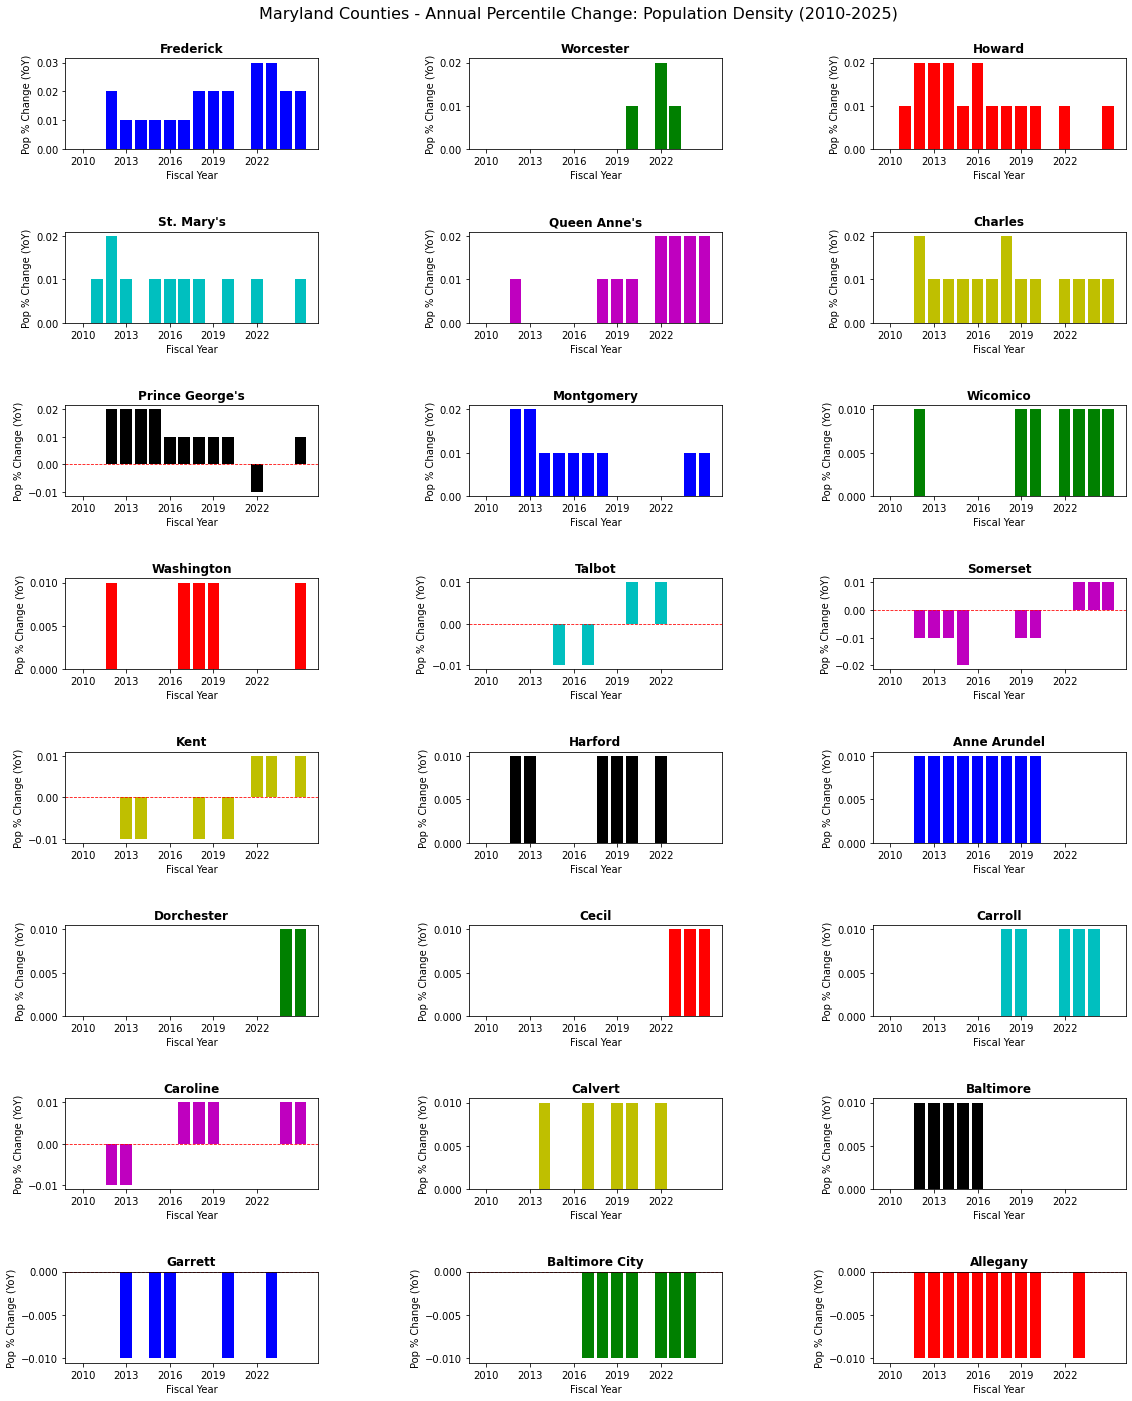

In [585]:
x = 0 #iterate through county names
n = 0 #iterate through subplot rows

color_w = 0
tracker = 0 #iterate through award rates


fig, axs = plt.subplots(8,3, figsize=(19,24))
fig.subplots_adjust(wspace=0.6, hspace=0.9)
fig.suptitle('Maryland Counties - Annual Percentile Change: Population Density (2010-2025)',  y = 0.91, fontsize=16)



for county in max.index:

    county_data = popden.loc[county]

    axs[n,x].bar(county_data.index.tolist(), county_data['YoY-PopDen'], color = color_wheel[color_w])
    axs[n,x].set_title(f"{county}", weight='bold')
    axs[n,x].set_ylabel("Pop % Change (YoY)", fontsize=10)
    axs[n,x].axhline(y=0, color='red', linewidth=0.8, linestyle='--')
    axs[n,x].set_xlabel("Fiscal Year")
    axs[n,x].set_xticks(np.arange(2010, 2025, 3))

    x = x + 1

    if x == 3:
        n = n + 1
        x = 0
    tracker = tracker + 1
    if color_w < 6:
        color_w = color_w + 1
    else:
        color_w = 0             
    
     
plt.plot()

In [593]:
max = popden.groupby('County')['Pop_Density'].max().sort_values(ascending=False) 
max.index

Index(['Baltimore City', 'Montgomery', 'Prince George's', 'Anne Arundel',
       'Baltimore', 'Howard', 'Harford', 'Frederick', 'Calvert', 'Carroll',
       'Charles', 'Washington', 'St. Mary's', 'Cecil', 'Wicomico', 'Allegany',
       'Queen Anne's', 'Talbot', 'Worcester', 'Caroline', 'Somerset', 'Kent',
       'Dorchester', 'Garrett'],
      dtype='object', name='County')

[]

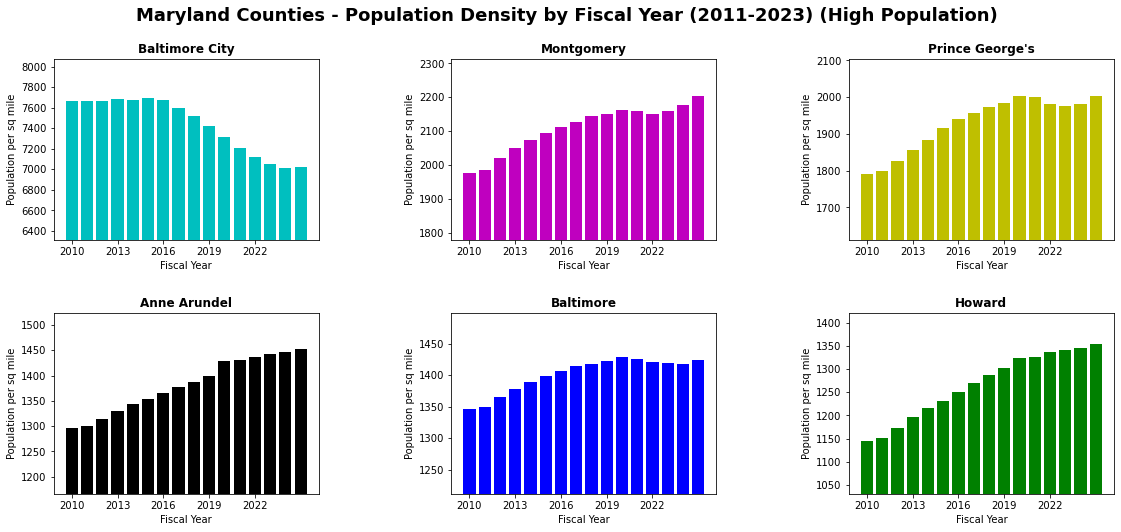

In [636]:
x = 0 #iterate through county names
n = 0 #iterate through subplot rows

color_w = 3
tracker = 0 #iterate through award rates


fig, axs = plt.subplots(2,3, figsize=(19,8))
fig.subplots_adjust(wspace=0.5, hspace=0.4)
fig.suptitle('Maryland Counties - Population Density by Fiscal Year (2011-2023) (High Population)',
             fontsize=18, weight = 'bold',y = 0.97)



for county in max.index:

    if tracker < 6:
        county_data = popden.loc[county]

        axs[n,x].bar(county_data.index.tolist(), county_data['Pop_Density'], color = color_wheel[color_w])
        axs[n,x].set_title(f"{county}", weight='bold')
        axs[n,x].set_ylabel("Population per sq mile", fontsize=10)
        #set minimum value for y axis
        axs[n,x].set_ylim(bottom=(county_data['Pop_Density'].min()-(0.1*county_data['Pop_Density'].min())))
        axs[n,x].set_xlabel("Fiscal Year")
        axs[n,x].set_xticks(np.arange(2010, 2025, 3))

        x = x + 1

        if x == 3:
            n = n + 1
            x = 0
        
        if color_w < 6:
            color_w = color_w + 1
        else:
            color_w = 0
         
        
    tracker = tracker + 1
plt.plot()

[]

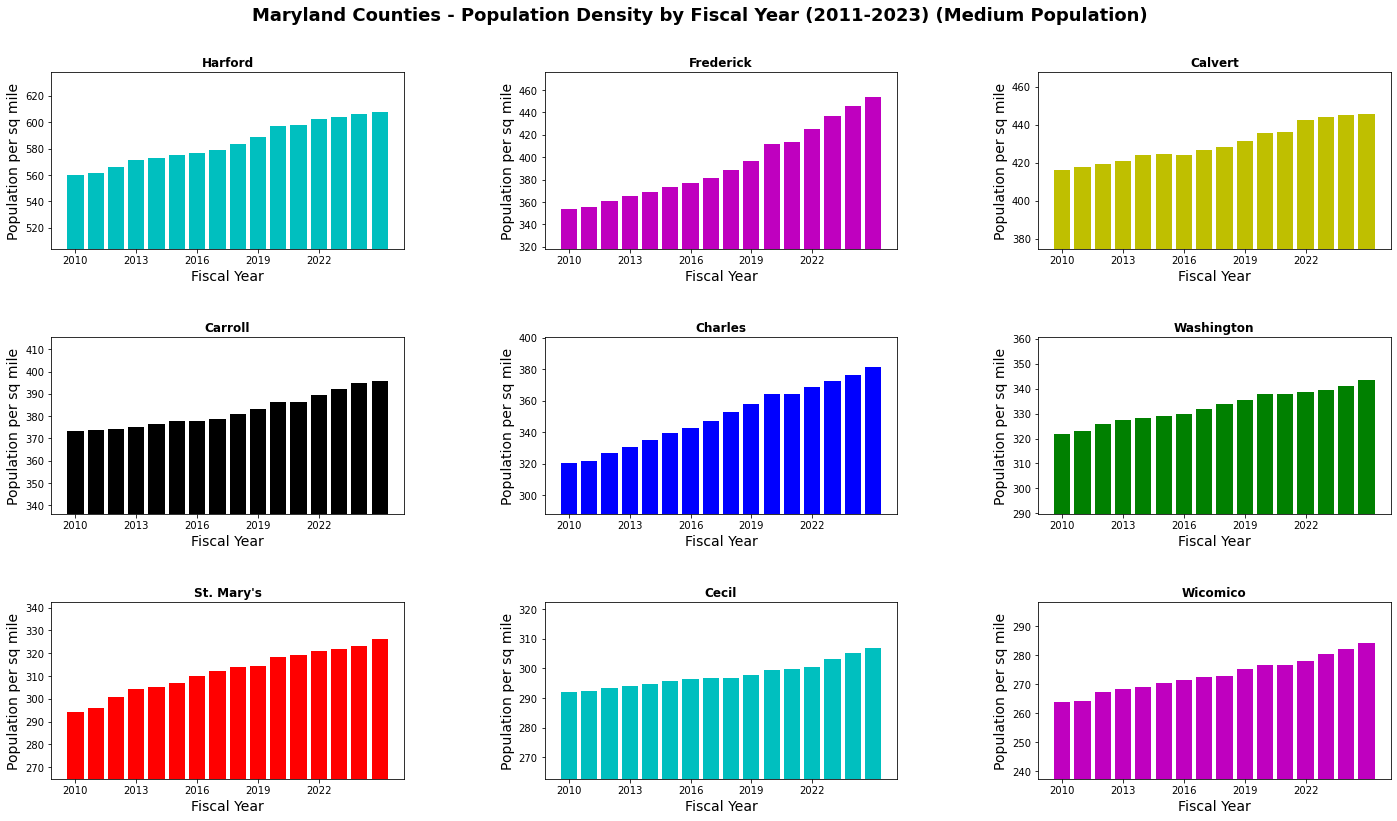

In [639]:
x = 0 #iterate through county names
n = 0 #iterate through subplot rows

color_w = 3
tracker = 0 #iterate through award rates


fig, axs = plt.subplots(3,3, figsize=(24,13))
fig.subplots_adjust(wspace=0.4, hspace=0.5)
fig.suptitle('Maryland Counties - Population Density by Fiscal Year (2011-2023) (Medium Population)',
              fontsize=18, weight = 'bold',y = 0.95)



for county in max.index:

    if tracker > 5 and tracker < 15:
        county_data = popden.loc[county]

        axs[n,x].bar(county_data.index.tolist(), county_data['Pop_Density'], color = color_wheel[color_w])
        axs[n,x].set_title(f"{county}", weight='bold')
        axs[n,x].set_ylabel("Population per sq mile", fontsize=14)
        #set minimum value for y axis
        axs[n,x].set_ylim(bottom=(county_data['Pop_Density'].min()-(0.1*county_data['Pop_Density'].min())))
        axs[n,x].set_xlabel("Fiscal Year",fontsize=14)
        axs[n,x].set_xticks(np.arange(2010, 2025, 3))

        x = x + 1

        if x == 3:
            n = n + 1
            x = 0
        
        if color_w < 6:
            color_w = color_w + 1
        else:
            color_w = 0
         
        
    tracker = tracker + 1
plt.plot()

[]

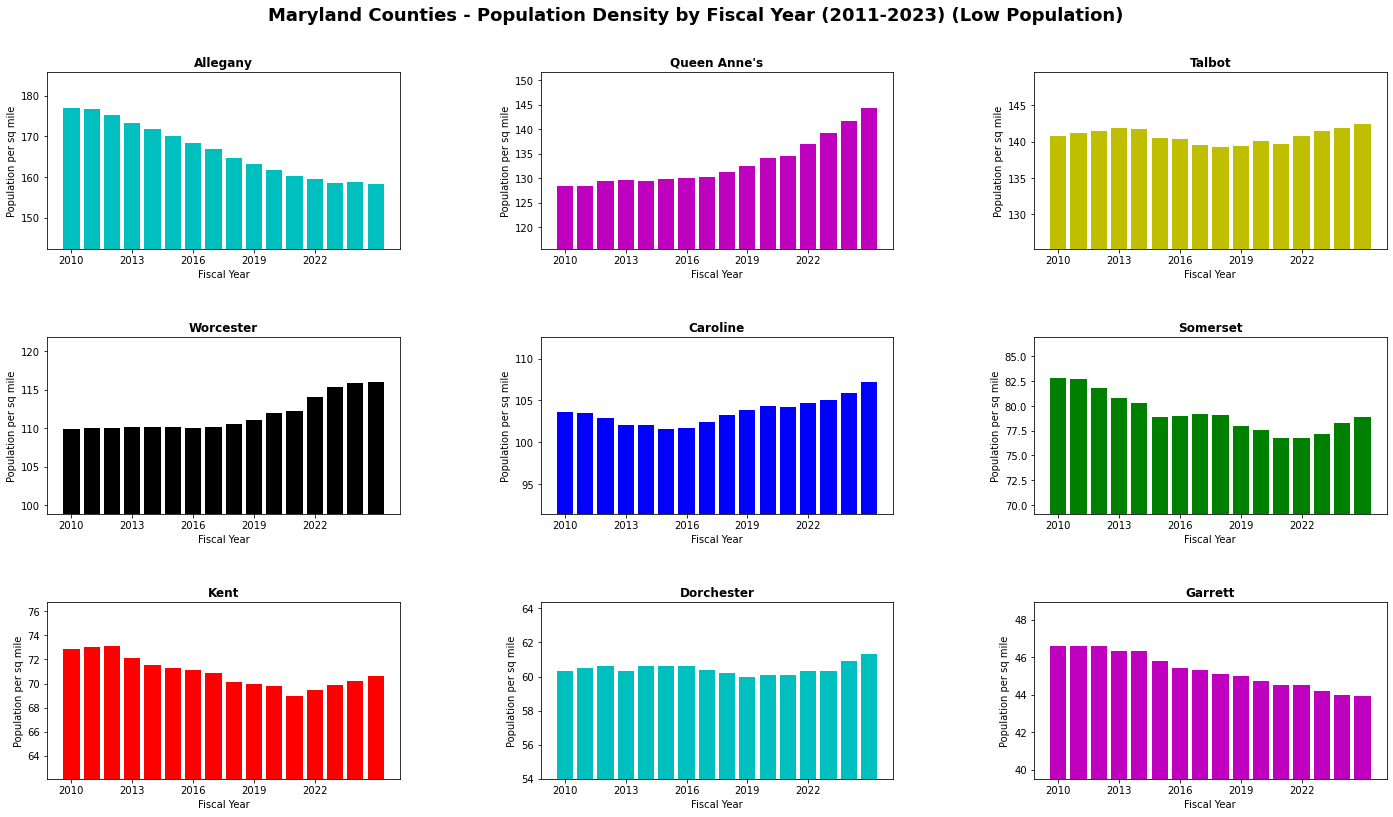

In [630]:
x = 0 #iterate through county names
n = 0 #iterate through subplot rows

color_w = 3
tracker = 0 #iterate through award rates


fig, axs = plt.subplots(3,3, figsize=(24,13))
fig.subplots_adjust(wspace=0.4, hspace=0.5)
fig.suptitle('Maryland Counties - Population Density by Fiscal Year (2011-2023) (Low Population)',
             fontsize=18, weight = 'bold',y = 0.95)



for county in max.index:

    if tracker > 14 and tracker < 26:
        county_data = popden.loc[county]

        axs[n,x].bar(county_data.index.tolist(), county_data['Pop_Density'], color = color_wheel[color_w])
        axs[n,x].set_title(f"{county}", weight='bold')
        axs[n,x].set_ylabel("Population per sq mile", fontsize=10)
        #set minimum value for y axis
        axs[n,x].set_ylim(bottom=(county_data['Pop_Density'].min()-(0.1*county_data['Pop_Density'].min())))
        axs[n,x].set_xlabel("Fiscal Year")
        axs[n,x].set_xticks(np.arange(2010, 2025, 3))

        x = x + 1

        if x == 3:
            n = n + 1
            x = 0
        
        if color_w < 6:
            color_w = color_w + 1
        else:
            color_w = 0
         
        
    tracker = tracker + 1
plt.plot()

In [556]:
a = [int(x) for x in popden.loc['Allegany'].index.tolist()]

a

[2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2020,
 2021,
 2022,
 2023,
 2024,
 2025]

In [557]:
yoy_pop.columns.get_loc('YoY-PopDen')

1

In [558]:
idx = pd.IndexSlice


# popden['YoY-PopDen'] = []
names = popden["County"].unique()
pops = popden.groupby('County')


# popden['pct'] = popden.sort_values('Fiscal Year').groupby(['County']).pct_change()


pops.head(5)
# for name in names:
#     # What is the year on year growth rate of population density for each county?
#     # temp = popden[popden['County'] == "county"]["Pop_Density"].pct_change()

#     popden.loc[idx[name], 'YoY-PopDen'] = popden.loc[idx[name], 'Pop_Density'].pct_change()
#     # popden.loc[idx[name], :]
#     # popden['pct'] = p, :]pct_change()

#     popden.groupby('County')['Fiscal Year'].pct_change()


# popden.head(5)


KeyError: 'County'

In [ ]:
popden.keys()

Index(['Pop_Density', 'YoY-PopDen'], dtype='object')

In [ ]:
idx = pandas.IndexSlice
# temp = popden[popden['County'] == "Calvert"]

popden.loc[idx['Calvert'], :]

,Pop_Density,YoY-PopDen
Fiscal Year,,
2010,416.3,NaN
2011,417.5,NaN
2012,419.0,NaN
2013,420.8,NaN
2014,424.1,NaN
2015,424.5,NaN
2016,424.2,NaN
2017,426.7,NaN
2018,428.4,NaN
